In [1]:
import numpy as np
import pandas as pd

In [2]:
# 데이터 생성
np.random.seed(42)
num_samples = 1000
classes = ['A', 'B', 'C']
df = pd.DataFrame({
    'feature1': np.random.normal(0, 1, num_samples),
    'feature2': np.random.normal(0, 1, num_samples),
    'class': np.random.choice(classes, num_samples, p=[0.5, 0.3, 0.2])
})

# 임의로 이상치 추가
outliers = pd.DataFrame({
    'feature1': [5, 6, 7],
    'feature2': [8, 9, 10],
    'class': ['A', 'B', 'C']
})

df = pd.concat([df, outliers], ignore_index=True)
df

,feature1,feature2,class
0,0.496714,1.399355,A
1,-0.138264,0.924634,A
2,0.647689,0.059630,A
3,1.523030,-0.646937,A
4,-0.234153,0.698223,C
...,...,...,...
998,-0.571179,-0.163067,A
999,0.572583,-0.744903,A
1000,5.000000,8.000000,A
1001,6.000000,9.000000,B


In [3]:
total_data = len(df)
num_outliers = len(outliers)
outlier_ratio = (num_outliers / total_data) * 100
print(f"이상치 비율: {outlier_ratio}%")


이상치 비율: 0.29910269192422734%


In [4]:
for cls in df['class'].unique():
    total = len(df[df['class'] == cls])
    outliers_in_class = len(outliers[outliers['class'] == cls])
    ratio = (outliers_in_class / total) * 100
    print(f"클래스 {cls}: 이상치 비율 {ratio:.2f}%")

클래스 A: 이상치 비율 0.20%
클래스 C: 이상치 비율 0.51%
클래스 B: 이상치 비율 0.32%


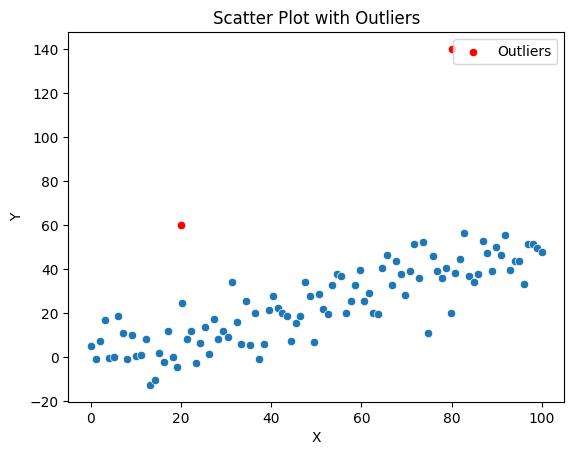

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# 데이터 생성
np.random.seed(42)
x = np.linspace(0, 100, 100)
y = 0.5 * x + np.random.normal(scale=10, size=100)

# 이상치 추가
outliers_x = [20, 80]
outliers_y = [60, 140]
x = np.append(x, outliers_x)
y = np.append(y, outliers_y)

data = pd.DataFrame({'x': x, 'y': y})

# 시각화
sns.scatterplot(data=data, x='x', y='y')
sns.scatterplot(x=outliers_x, y=outliers_y, color='red', label='Outliers')
plt.title('Scatter Plot with Outliers')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

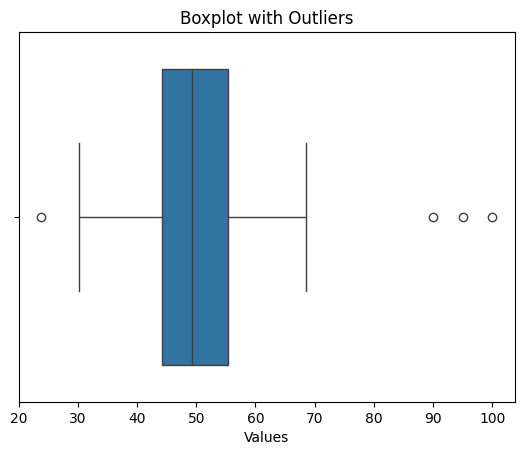

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# 데이터 생성
np.random.seed(42)
data = np.random.normal(loc=50, scale=10, size=100)
outliers = [90, 95, 100]  # 이상치 추가
data = np.append(data, outliers)

# 데이터프레임 생성
df_value = pd.DataFrame({'value': data})

# Boxplot 시각화
sns.boxplot(data=df_value, x='value')
plt.title('Boxplot with Outliers')
plt.xlabel('Values')
plt.show()

f:\practice\learn-thetheory-through-practice\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
f:\practice\learn-thetheory-through-practice\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50672 (\N{HANGUL SYLLABLE YEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
f:\practice\learn-thetheory-through-practice\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
f:\practice\learn-thetheory-through-practice\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47084 (\N{HANGUL SYLLABLE REO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
f:\practice\learn-thetheory-through-practice\.venv\Lib\site-packages\IPython\core\pylabt

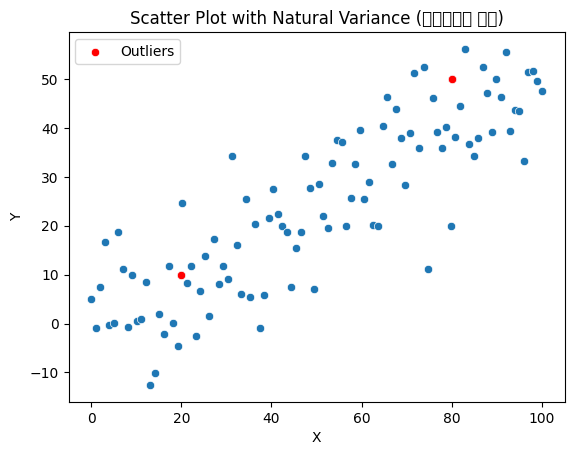

In [7]:
# 자연스러운 변동을 반영한 이상치 예제
np.random.seed(42)
x = np.linspace(0, 100, 100)
y = 0.5 * x + np.random.normal(scale=10, size=100)

# 이상치 추가 (경향성을 따름)
outliers_x = [20, 80]
outliers_y = [10, 50]  # 자연스러운 변동 예제
x = np.append(x, outliers_x)
y = np.append(y, outliers_y)

df_value_natural_variance= pd.DataFrame({'x': x, 'y': y})

# 시각화
sns.scatterplot(data=df_value_natural_variance, x='x', y='y')
sns.scatterplot(x=outliers_x, y=outliers_y, color='red', label='Outliers')
plt.title('Scatter Plot with Natural Variance (자연스러운 변동)')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

In [8]:
%pip install scikit-learn
# !pip 가 아니라 %pip 설치해야함.

Note: you may need to restart the kernel to use updated packages.


In [9]:
from sklearn.cluster import DBSCAN

In [10]:
df

,feature1,feature2,class
0,0.496714,1.399355,A
1,-0.138264,0.924634,A
2,0.647689,0.059630,A
3,1.523030,-0.646937,A
4,-0.234153,0.698223,C
...,...,...,...
998,-0.571179,-0.163067,A
999,0.572583,-0.744903,A
1000,5.000000,8.000000,A
1001,6.000000,9.000000,B


In [11]:
df_new = df.drop(columns=['class'])
dbscan = DBSCAN(eps=0.5, min_samples=5).fit(df_new)

In [12]:

df['cluster'] = dbscan.labels_
outliers = df[df['cluster'] == -1]  # DBSCAN에서 -1은 이상치를 나타냄
print(outliers['cluster'].value_counts())

cluster
-1    8
Name: count, dtype: int64
